In [1]:
"""
================================================================================
INICIAÇÃO CIENTÍFICA - ANÁLISE DE SINAIS sEMG (Eletromiografia de Superfície)
================================================================================
Aluno: Anderson Rafael da Silva Lesniewski
RA: 1991329
Orientador: Dr Fabio Luiz Bertotti
Data: Novembro 2025

Tema: Extração de Características Simples
================================================================================
"""

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.io import loadmat

plt.rcParams['figure.figsize'] = (12, 4)
plt.rcParams['font.size'] = 10

print("="*80)
print(" EXTRAÇÃO DE CARACTERÍSTICAS SIMPLES - SINAIS sEMG REAIS")
print("="*80)
print()


 EXTRAÇÃO DE CARACTERÍSTICAS SIMPLES - SINAIS sEMG REAIS



Arquivos disponíveis: ['S1_A1_E1.mat', 'S1_A1_E2.mat', 'S1_A1_E3.mat']
Formato da matriz EMG: (101014, 10)


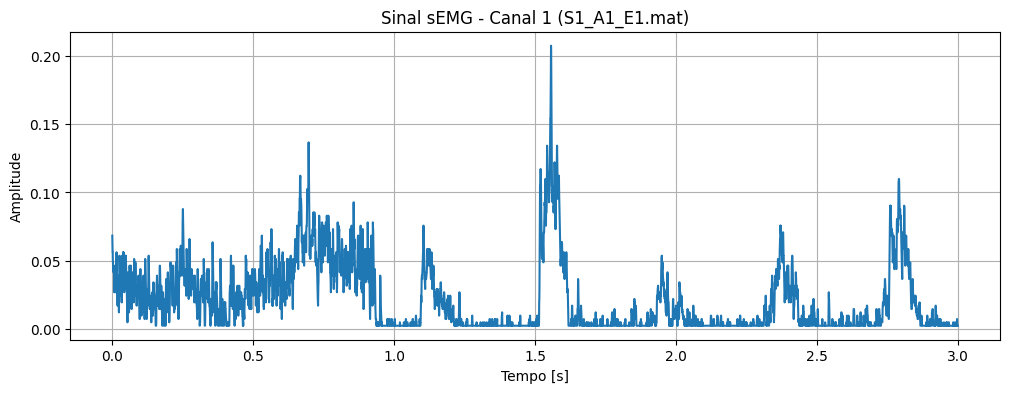

In [2]:
# ------------------------------------------------------------------------------
# BLOCO 2 - Carregamento dos dados reais (NinaPro DB1 - Subject 1)
# ------------------------------------------------------------------------------

from scipy.io import loadmat
import os
import numpy as np
import matplotlib.pyplot as plt

base_path = "../data/s1/"

# listar os arquivos disponíveis
arquivos = os.listdir(base_path)
print("Arquivos disponíveis:", arquivos)

# escolher um exercício (E1, E2 ou E3)
arquivo = "S1_A1_E1.mat"
data = loadmat(base_path + arquivo)

# extrair matriz EMG
emg = data["emg"]
print("Formato da matriz EMG:", emg.shape)

# usar o canal 1
canal = emg[:, 0]

# taxa de amostragem do NinaPro DB1 (confirmada)
fs = 2000  

# vetor de tempo
tempo = np.arange(len(canal)) / fs

# plotar 3 segundos para visualização
trecho = int(fs * 3)

plt.plot(tempo[:trecho], canal[:trecho])
plt.title(f"Sinal sEMG - Canal 1 ({arquivo})")
plt.xlabel("Tempo [s]")
plt.ylabel("Amplitude")
plt.grid(True)
plt.show()


In [3]:
def rms(signal):
    return np.sqrt(np.mean(signal**2))

def mav(signal):
    return np.mean(np.abs(signal))

def var(signal):
    return np.var(signal)

def ssc(signal, threshold=1e-6):
    count = 0
    for i in range(1, len(signal)-1):
        diff1 = signal[i] - signal[i-1]
        diff2 = signal[i+1] - signal[i]
        if (diff1 * diff2 < 0) and (abs(diff1 - diff2) > threshold):
            count += 1
    return count

def waveform_length(signal):
    return np.sum(np.abs(np.diff(signal)))

def extract_features(signal, window=400, overlap=0.5):
    step = int(window * (1 - overlap))
    features = []

    for i in range(0, len(signal) - window, step):
        segment = signal[i:i+window]

        features.append([
            rms(segment),
            mav(segment),
            var(segment),
            waveform_length(segment),
            ssc(segment)  # nova feature
        ])

    columns = ["RMS", "MAV", "VAR", "WL", "SSC"]
    return pd.DataFrame(features, columns=columns)

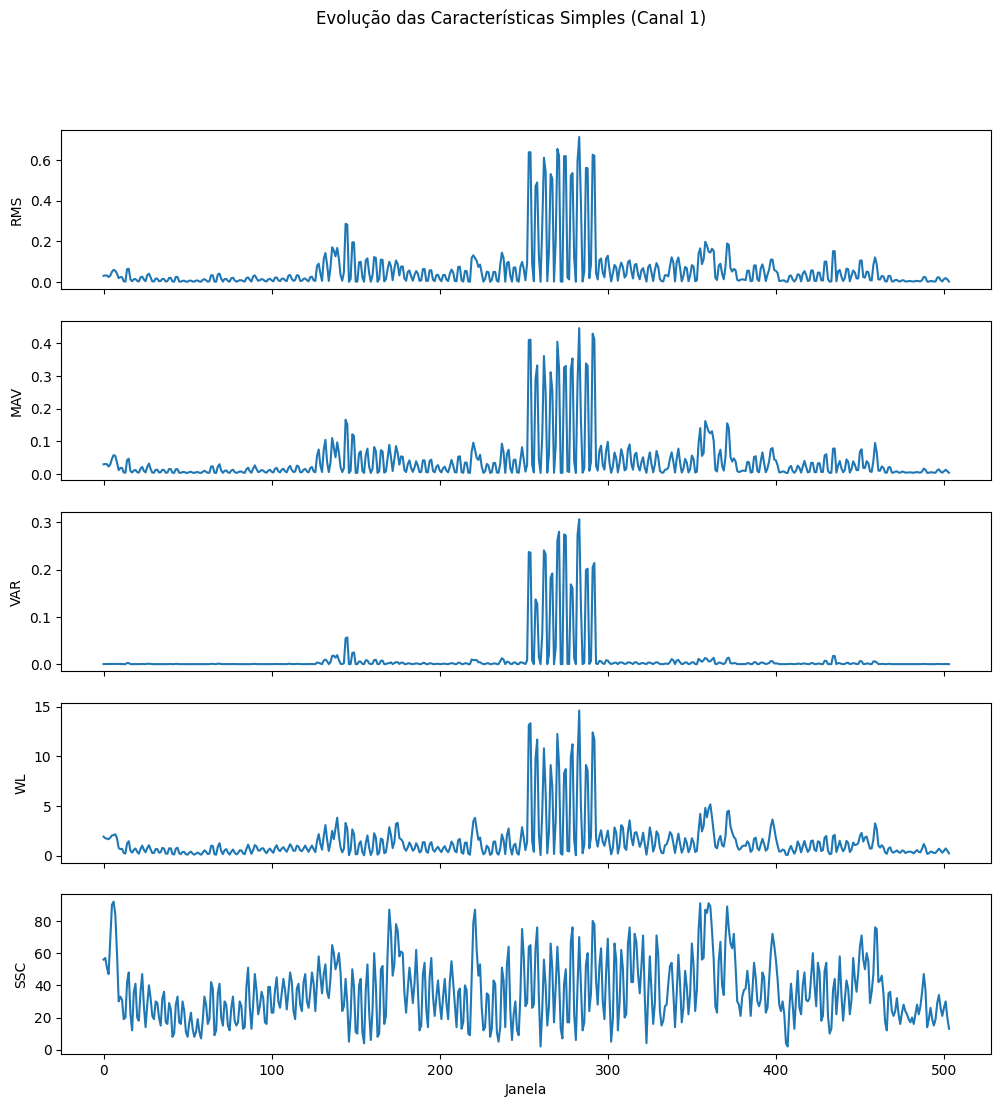

In [4]:
# Selecionar canal para análise
canal = emg[:, 0]
features_df = extract_features(canal, window=400, overlap=0.5)

fig, axs = plt.subplots(5, 1, figsize=(12, 12), sharex=True)

for i, col in enumerate(features_df.columns):
    axs[i].plot(features_df[col])
    axs[i].set_ylabel(col)

axs[-1].set_xlabel("Janela")
plt.suptitle("Evolução das Características Simples (Canal 1)")
plt.show()

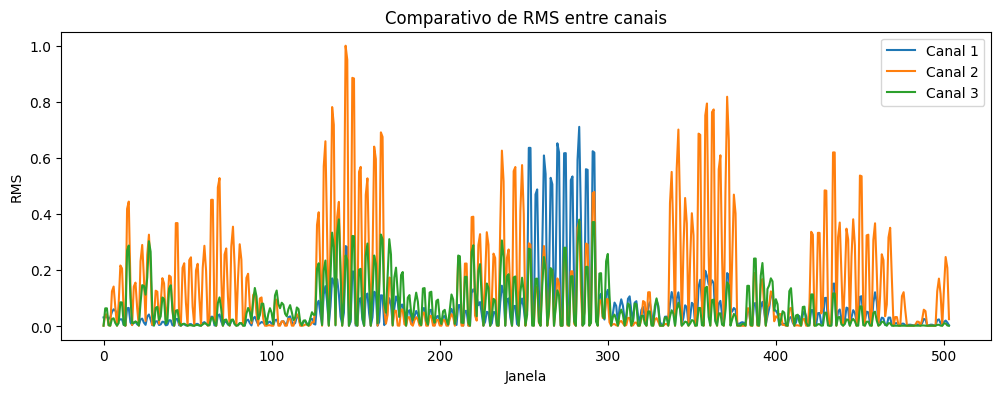

In [5]:
features_all = []
for ch in range(3):  # ex.: comparar 3 canais
    f_df = extract_features(emg[:, ch])
    f_df["Canal"] = ch + 1
    features_all.append(f_df)

features_all = pd.concat(features_all)

# Exemplo: comparar RMS entre canais
plt.figure(figsize=(12, 4))
for ch in features_all["Canal"].unique():
    subset = features_all[features_all["Canal"] == ch]
    plt.plot(subset["RMS"], label=f"Canal {ch}")
plt.legend()
plt.title("Comparativo de RMS entre canais")
plt.xlabel("Janela")
plt.ylabel("RMS")
plt.show()


In [8]:
print("Conclusões:")
print("- Inicialmente utilizamos a feature ZC, mas como o sinal da base NinaPro DB1 é retificado,")
print("  não há cruzamentos de zero; por isso substituímos o ZC pela métrica SSC.")
print("- As features RMS, MAV, Variância, WL e SSC mostraram padrões claros e coerentes de")
print("  ativação muscular ao longo do exercício.")
print("- Essas cinco características servirão como base para as próximas etapas de classificação")
print("  previstas para as semanas 7-8.")

Conclusões:
- Inicialmente utilizamos a feature ZC, mas como o sinal da base NinaPro DB1 é retificado,
  não há cruzamentos de zero; por isso substituímos o ZC pela métrica SSC.
- As features RMS, MAV, Variância, WL e SSC mostraram padrões claros e coerentes de
  ativação muscular ao longo do exercício.
- Essas cinco características servirão como base para as próximas etapas de classificação
  previstas para as semanas 7-8.
